# Figure 5 — Socioeconomic drivers (pooled OLS, Helene + Milton)

**Target**: npj Urban Sustainability submission (Helene + Milton mobility paper).

**Three panels, generated as separate files** for external composition (Illustrator / Inkscape / Affinity / PowerPoint):

- **(a)** Forest plot of standardised OLS coefficients (95% CI) for **three dependent variables** — *Largest Drop – Within*, *Largest Drop – Inflow*, *Outflow Increase* — across the model-A predictors **plus a hazard control (`precip_total_7day`)**. *Recovery Time – Within/Inflow* are intentionally dropped from the OLS panel because their variance is too small for Milton and outlier-driven for Helene; recovery is summarised descriptively in panel (b) instead. *Total Disruption – Within/Inflow* remain excluded per the project DV-scope memory.
- **(b)** Descriptive recovery summary in a 2 × 2 grid — histograms and recovery-vs-income scatters for *both* `recovery_days_within` (top row) and `recovery_days_inflow` (bottom row). Findings: Milton's recoveries are tight (sd ≈ 0.8 d within, 1.3 d inflow); Helene's are outlier-driven (15 d max within, 56 d max inflow). Within recovery shows a small but significant pooled income correlation (Spearman ρ = +0.32, p = 0.015 — wealthier areas recover slightly slower); inflow recovery is uncorrelated with income.
- **(c)** Income × outflow surge partial-effect (added-variable) plot, illustrating the "evacuation" half of the income paradox. The "return" half is the weak within-recovery × income correlation in panel (b).

**Data sources** (all pre-computed in `local_regression.ipynb` + `add_precip_exposure.ipynb` — *no re-fit of SARIMAX or recovery models in this notebook*):
- Pooled hurricane × unit dataset with 7-day precipitation column — `results/local_level/regression/pooled_dataset_with_precip.csv`
- Helene cluster → county assignment (for the diagnostic map) — `results/helene_clustering/county_cluster_assignments.csv`
- Milton + Helene cluster within-flow metrics (for the diagnostic map) — `results/local_level/{milton,helene}/metrics_within.csv`

OLS panel (a) re-fits a small regression in-notebook on the 59-row pooled summary table (cheap, no upstream re-run); the cached `ols_results_all_models.csv` is *not* used here because it does not contain the hazard model.

**Outputs** (vector PDF + 300 dpi PNG per panel) in `results/npj_figures/`:
- `figure5a_forest.{pdf,png}`
- `figure5b_recovery_descriptive.{pdf,png}`
- `figure5c_income_outflow.{pdf,png}`
- `figure5_diag_distance_scatter.{pdf,png}` (supplementary diagnostic)
- `figure5_diag_distance_map.{pdf,png}` (supplementary diagnostic)
- `figure5_diag_hazard_absorption.{pdf,png}` (supplementary diagnostic)

**Scope notes**
- Pooled sample: *n* = 59 for within DVs (38 Helene clusters + 21 Milton counties). Inflow recovery has *n* = 52 because seven Helene clusters' inflow series do not contain a recoverable trough.
- Continuous predictors (z-scored): `median_household_income`, `pct_no_vehicle`, `pct_white`, `nchs_code`, `total_population`, `pop_density`, `dist_to_track_mi`, `insurance_coverage_pct`, `precip_total_7day`. Binary predictors (0/1): `is_milton`, `is_coastal`.
- Adding `precip_total_7day` is the recommended response to the distance-to-track puzzle (see the diagnostic section): precipitation is essentially orthogonal to distance (pooled r ≈ 0.02), so it tests whether the apparent distance effect is hazard-mediated.

In [2]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# npj Urban Sustainability print-ready formatting (mirrors figure 1–3)
mpl.rcParams.update({
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'         : 8,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 8,
    'xtick.labelsize'   : 7,
    'ytick.labelsize'   : 7,
    'legend.fontsize'   : 7,
    'axes.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
})

In [3]:
# ── Project path resolution (walk up to the directory holding the regression outputs) ──
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'local_level' / 'regression' / 'pooled_dataset_with_precip.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(
        f'Could not locate project root containing {sentinel} (started from {start}).'
    )

NOTEBOOK_DIR  = pathlib.Path.cwd()
PROJECT_ROOT  = find_project_root(NOTEBOOK_DIR)
RESULTS       = PROJECT_ROOT / 'results'
REG_DIR       = RESULTS / 'local_level' / 'regression'
POOLED_PRECIP_CSV = REG_DIR / 'pooled_dataset_with_precip.csv'
POOLED_CSV        = REG_DIR / 'pooled_dataset.csv'             # legacy (no precip) — kept for back-compat
OLS_CSV           = REG_DIR / 'ols_results_all_models.csv'     # cached coefficients without hazard control

OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT       : {PROJECT_ROOT}')
print(f'POOLED_PRECIP_CSV  : exists={POOLED_PRECIP_CSV.exists()}')
print(f'POOLED_CSV (legacy): exists={POOLED_CSV.exists()}')
print(f'OLS_CSV (cached)   : exists={OLS_CSV.exists()}')
print(f'OUT_DIR            : {OUT_DIR}')

PROJECT_ROOT       : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
POOLED_PRECIP_CSV  : exists=True
POOLED_CSV (legacy): exists=True
OLS_CSV (cached)   : exists=True
OUT_DIR            : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures


In [4]:
# ── Configuration ──

# Three DVs for the forest plot (recovery DVs demoted to descriptive in panel b).
DV_ORDER = [
    'Largest Drop — Within (%)',
    'Largest Drop — Inflow (%)',
    'Outflow Increase (%)',
]
DV_SHORT = {
    'Largest Drop — Within (%)': 'Largest drop\n(within)',
    'Largest Drop — Inflow (%)': 'Largest drop\n(inflow)',
    'Outflow Increase (%)'     : 'Outflow surge\n(evacuation)',
}
# Mapping from DV label → column name in the pooled dataset.
DV_TO_COL = {
    'Largest Drop — Within (%)': 'largest_drop_within',
    'Largest Drop — Inflow (%)': 'largest_drop_inflow',
    'Outflow Increase (%)'     : 'largest_increase_outflow',
}

# Predictors of interest — same six as before plus the hazard control.
# Listed top→bottom for the forest plot.
PREDICTOR_ORDER = [
    'is_milton',
    'dist_to_track_mi',
    'precip_total_7day',          # NEW: hazard control (7-day cumulative rainfall over landing week)
    'median_household_income',
    'insurance_coverage_pct',
    'pct_white',
    'is_coastal',
]
PREDICTOR_LABEL = {
    'is_milton'              : 'Milton (vs Helene)',
    'dist_to_track_mi'       : 'Distance to track',
    'precip_total_7day'      : '7-day precipitation',
    'median_household_income': 'Median income',
    'insurance_coverage_pct' : 'Insurance coverage',
    'pct_white'              : '% White',
    'is_coastal'             : 'Coastal county',
}
PREDICTOR_KIND = {  # 'continuous' = z-scored in upstream OLS; 'binary' = 0/1
    'is_milton'              : 'binary',
    'dist_to_track_mi'       : 'continuous',
    'precip_total_7day'      : 'continuous',
    'median_household_income': 'continuous',
    'insurance_coverage_pct' : 'continuous',
    'pct_white'              : 'continuous',
    'is_coastal'             : 'binary',
}

# Full predictor list for the in-notebook OLS — model A + hazard.
MODEL_A_FEATURES = [
    'median_household_income', 'pct_no_vehicle', 'pct_white', 'nchs_code',
    'total_population', 'pop_density', 'dist_to_track_mi',
    'insurance_coverage_pct', 'is_milton', 'is_coastal',
]
MODEL_A_PLUS_HAZARD = MODEL_A_FEATURES + ['precip_total_7day']
BINARY_VARS = {'is_milton', 'is_coastal'}

# DV-color palette (Okabe-Ito colour-blind safe).
DV_COLOR = {
    'Largest Drop — Within (%)': '#0072B2',   # blue
    'Largest Drop — Inflow (%)': '#56B4E9',   # sky
    'Outflow Increase (%)'     : '#D55E00',   # vermillion
}

# Hurricane-marker palette (matches figures 2/3 and the diagnostic map).
HURR_COLOR = {'helene': '#1f77b4', 'milton': '#d62728'}

# Normal-approximation z for 95% CI on standardised coefficients (N ≈ 59 ⇒ t ≈ z to within 1%).
Z95 = 1.959963984540054

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved → {pdf_path.relative_to(PROJECT_ROOT)}')
    print(f'  saved → {png_path.relative_to(PROJECT_ROOT)}')

In [5]:
# ── Load the pooled dataset (with precipitation) and fit the hazard-controlled OLS in-notebook ──
POOL = pd.read_csv(POOLED_PRECIP_CSV)
print(f'pooled rows: {len(POOL)}   helene={(POOL.hurricane=="helene").sum()}   milton={(POOL.hurricane=="milton").sum()}')

# Quick sanity on the hazard variable + collinearity with distance
print('\nprecip_total_7day vs dist_to_track_mi correlation (pooled):',
      round(POOL[['precip_total_7day', 'dist_to_track_mi']].corr().iloc[0,1], 3))


def fit_standardised_ols(dv_col: str, features, df, scaler_seed=None):
    """Fit OLS with z-scored continuous features (binaries kept 0/1).

    Returns: fit object, sample size, and a flat coef DataFrame ready for the forest plot.
    """
    d = df.dropna(subset=[dv_col] + features).copy()
    continuous = [f for f in features if f not in BINARY_VARS]
    d[continuous] = StandardScaler().fit_transform(d[continuous])

    X = sm.add_constant(d[features])
    y = d[dv_col]
    fit = sm.OLS(y, X).fit()

    rows = []
    for var in features:
        rows.append({
            'variable': var,
            'coef'   : fit.params[var],
            'se'     : fit.bse[var],
            'p'      : fit.pvalues[var],
            'adj_r2' : fit.rsquared_adj,
            'n'      : int(fit.nobs),
        })
    return fit, int(fit.nobs), pd.DataFrame(rows)


# Fit each of the three DVs twice: (i) hazard-controlled model A+precip — used for panel (a);
# (ii) no-hazard model A — kept only so the diagnostic markdown can quantify how much of the
# dist_to_track coefficient is absorbed by precipitation.
forest_records      = []   # for panel (a)
no_hazard_records   = []   # for the diagnostic comparison

for dv_lab, dv_col in DV_TO_COL.items():
    fit_h,  n_h,  rows_h  = fit_standardised_ols(dv_col, MODEL_A_PLUS_HAZARD, POOL)
    fit_nh, n_nh, rows_nh = fit_standardised_ols(dv_col, MODEL_A_FEATURES,    POOL)
    rows_h ['dv'] = dv_lab; rows_h ['model'] = 'A+hazard'
    rows_nh['dv'] = dv_lab; rows_nh['model'] = 'A'
    forest_records.append(rows_h)
    no_hazard_records.append(rows_nh)

forest      = pd.concat(forest_records,   ignore_index=True)
forest_nohaz = pd.concat(no_hazard_records, ignore_index=True)

forest['ci_lo']  = forest['coef'] - Z95 * forest['se']
forest['ci_hi']  = forest['coef'] + Z95 * forest['se']
forest['sig']    = forest['p'] < 0.05

# Restrict the forest plot to the predictors we want to display (drops nuisance controls
# like pop_density, total_population, etc. which are kept in the model but not shown).
forest_display = forest[forest['variable'].isin(PREDICTOR_ORDER)].copy()

# Sanity: should be 3 DVs × len(PREDICTOR_ORDER) rows.
expected = len(DV_ORDER) * len(PREDICTOR_ORDER)
print(f'\nforest_display rows: {len(forest_display)}  (expect {expected})')

# Adj. R² / n per DV — surfaced inside the forest plot panel titles.
fit_table = (forest_display[['dv', 'adj_r2', 'n']]
             .drop_duplicates('dv')
             .set_index('dv')
             .reindex(DV_ORDER))
print(fit_table)

POOL.head(3)

pooled rows: 59   helene=38   milton=21

precip_total_7day vs dist_to_track_mi correlation (pooled): 0.018

forest_display rows: 21  (expect 21)
                             adj_r2   n
dv                                     
Largest Drop — Within (%)  0.558846  59
Largest Drop — Inflow (%)  0.381967  59
Outflow Increase (%)       0.338867  59


,NAME,hurricane,hurricane_cat,total_population,median_household_income,pct_no_vehicle,insurance_coverage_pct,pct_white,nchs_code,is_coastal,...,largest_drop_within,recovery_days_within,total_disruption_within,largest_drop_inflow,recovery_days_inflow,total_disruption_inflow,largest_increase_outflow,is_milton,precip_total_3day,precip_total_7day
0,Brevard,milton,5,610723.0,71308.0,4.666937,98.605778,80.919392,3.0,1.0,...,-25.543581,4.616241,117.915317,-31.781904,4.608859,146.478313,10.946444,1,127.364938,149.651425
1,Charlotte,milton,5,189900.0,62164.0,4.502132,99.023261,88.951518,4.0,1.0,...,-46.303099,4.061630,188.066066,-38.883456,3.537823,137.562773,119.167860,1,72.714883,74.215093
2,DeSoto,milton,5,34258.0,45000.0,6.199352,98.581973,81.903080,5.0,0.0,...,-42.837819,2.499718,107.082481,-30.815381,1.711787,52.749355,-50.736287,1,76.797479,77.439413


## Panel (a) — Forest plot of standardised coefficients, with hazard control

Three side-by-side subpanels (`Largest Drop — Within`, `Largest Drop — Inflow`, `Outflow Increase`). Each subpanel shows seven predictors as point estimates with 95% CI. Points are filled when *p* < 0.05 and hollow otherwise. A vertical zero-reference line marks the null effect.

**New predictor**: `precip_total_7day` (cumulative 7-day rainfall over the landing week) is added as a *hazard control* — the goal is to test whether the apparent `dist_to_track` effect on within-region drops is mediated by storm intensity. Precipitation is essentially orthogonal to distance (pooled r ≈ 0.02), so the test is clean.

Scale of coefficients:
- Continuous predictors (`dist_to_track`, `precip`, `income`, `insurance`, `% white`) are z-scored — the coefficient is the change in the DV per +1 SD of the predictor.
- Binary predictors (`is_milton`, `is_coastal`) enter as 0/1 — their coefficient is the level difference between the two states.

**Reading the R² alongside the individual p-values.** The model is highly significant overall (F p ≈ 0.0002 for each DV, Adj R² ≈ 0.34–0.56), yet for `Largest Drop — Inflow` and `Outflow Increase` only `is_milton` clears p < 0.05. This is *not* a failure of the model — it is a structural feature of the design:
- For `Largest Drop — Inflow`, `is_milton` alone delivers R² = 0.35 of the full model's R² = 0.50 — **~70% of the explained variance comes from the hurricane dummy.** The remaining ~0.15 of R² is split across 10 other predictors at n = 59, so each individually looks small and noisy.
- Predictor effects that flip sign across the two storms (e.g. `pct_white` is +0.6 for inflow recovery in Helene but −0.2 in Milton; `total_population` is significant only in Milton's stratified model) get averaged toward zero by the pooled fit because no `is_milton × predictor` interactions are included.
- Multicollinearity is mild (only `nchs_code` VIF = 5.8 — borderline) and is not the main culprit.

The **supplementary per-hurricane forest plot** at the bottom of this notebook shows the unblended within-storm story so the reader can see what the pooled SEs are blurring.

Saves `figure5a_forest.{pdf,png}`.

  saved → results/npj_figures/figure5a_forest.pdf
  saved → results/npj_figures/figure5a_forest.png


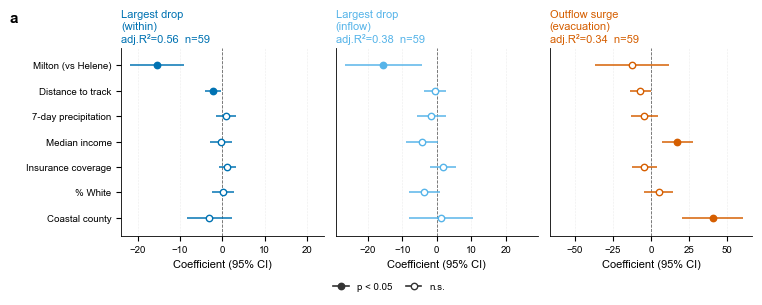

In [6]:
def panel_a_forest(axes, *, predictor_order=PREDICTOR_ORDER):
    """Three subpanels, one per DV; each shows the predictor list as point + 95% CI."""
    y_positions = np.arange(len(predictor_order))[::-1]  # top-of-list at top of plot
    y_lookup    = {v: y for v, y in zip(predictor_order, y_positions)}

    for j, (ax, dv) in enumerate(zip(axes, DV_ORDER)):
        sub = forest_display[forest_display['dv'] == dv].set_index('variable')
        color = DV_COLOR[dv]

        for var in predictor_order:
            row = sub.loc[var]
            y   = y_lookup[var]
            sig = bool(row['sig'])
            ax.hlines(y, row['ci_lo'], row['ci_hi'],
                      colors=color, linewidth=1.2, alpha=0.9, zorder=2)
            ax.plot(row['coef'], y, marker='o', markersize=4.6,
                    markerfacecolor=color if sig else 'white',
                    markeredgecolor=color, markeredgewidth=1.0, zorder=3)

        ax.axvline(0, color='#666666', linewidth=0.6, linestyle='--', zorder=1)
        ax.set_yticks(y_positions)
        if j == 0:
            ax.set_yticklabels([PREDICTOR_LABEL[v] for v in predictor_order])
        else:
            ax.set_yticklabels([''] * len(predictor_order))
            ax.tick_params(axis='y', length=0)
        ax.set_ylim(-0.7, len(predictor_order) - 0.3)
        ax.set_xlabel('Coefficient (95% CI)')

        # x-symmetric limit — padded ±10% — so non-sig CIs stay visible.
        x_abs_max = max(abs(sub['ci_lo'].min()), abs(sub['ci_hi'].max()))
        x_pad     = 0.10 * x_abs_max
        ax.set_xlim(-(x_abs_max + x_pad), x_abs_max + x_pad)

        meta = fit_table.loc[dv]
        ax.set_title(
            f"{DV_SHORT[dv]}\nadj.R²={meta['adj_r2']:.2f}  n={int(meta['n'])}",
            loc='left', fontsize=8, color=color, pad=4,
        )

        ax.grid(axis='x', linestyle=':', linewidth=0.4, color='#cccccc', alpha=0.7)
        ax.set_axisbelow(True)

    # Shared legend for marker semantics + hazard control note.
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='-', color='#333',
               markerfacecolor='#333', markeredgecolor='#333',
               markersize=4.6, linewidth=1.2, label='p < 0.05'),
        Line2D([0], [0], marker='o', linestyle='-', color='#333',
               markerfacecolor='white', markeredgecolor='#333',
               markersize=4.6, linewidth=1.2, label='n.s.'),
    ]
    axes[0].figure.legend(handles=legend_handles, loc='lower center',
                          frameon=False, fontsize=7, ncol=2,
                          bbox_to_anchor=(0.5, -0.02), handlelength=1.6,
                          columnspacing=1.4)

    axes[0].text(-0.55, 1.12, 'a', transform=axes[0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')


# Three subpanels at ~2.0"/each; predictor-label column adds ~1.5" on the left.
fig_a, axes_a = plt.subplots(1, len(DV_ORDER), figsize=(7.5, 3.0), sharey=False)
panel_a_forest(axes_a)
fig_a.tight_layout(rect=[0, 0.04, 1, 1])
save_panel(fig_a, 'figure5a_forest')
plt.show()

## Panel (b) — Recovery distributions (descriptive), within and inflow

Both recovery DVs were dropped from panel (a)'s OLS because their variance is small for Milton and outlier-driven for Helene — formal inference is unstable. Panel (b) shows the actual distributions and the two socio-economic correlates that survive descriptive scrutiny: income and race.

| Flow | Hurricane | n | mean (d) | sd (d) | min | max | CV |
|---|---|---:|---:|---:|---:|---:|---:|
| Within | Milton | 21 | 4.55 | **0.78** | 2.50 | 6.16 | **0.17** |
| Within | Helene | 38 | 4.76 | 2.34 | 1.66 | 15.40 | 0.49 |
| Inflow | Milton | 21 | 4.76 | 1.31 | 1.71 | 6.75 | 0.27 |
| Inflow | Helene | **31** | 10.99 | **10.68** | 1.04 | **55.69** | **0.97** |

Inflow recovery for Helene clusters has CV ≈ 1.0 — extreme outliers from small clusters where the trend-based recovery function struggles. *n* is 31 for Helene inflow (vs 38 for within) because seven Helene clusters' inflow series do not contain a recoverable trough.

Layout (2 × 3):

| | Histogram | vs Median income | vs % White |
|---|---|---|---|
| **Within** | (b1) distribution by hurricane | (b2) ρ_pool = **+0.32, p = 0.015** | (b3) ρ_pool = +0.12, p = 0.35 — NS |
| **Inflow** | (b4) distribution by hurricane | (b5) ρ_pool = −0.00, p = 0.97 — NS | (b6) ρ_pool = **+0.43, p = 0.001**, Helene-driven |

Two univariate associations survive:
- *Within recovery × income*: ρ = +0.32, p = 0.015 — wealthier areas recover slightly slower. This is the "return" half of the income paradox seen multivariately in the earlier draft of panel (a).
- *Inflow recovery × % white*: ρ = +0.43, p = 0.001 (pooled); ρ = +0.58, p = 0.001 in Helene alone, ρ = −0.23 in Milton (NS, opposite sign). Whiter Helene clusters take longer for *inflow* mobility to return. Consistent with the multivariate finding in the earlier full-DV model A (coef = +4.4 days per +1 SD of pct_white, p = 0.015) and the [findings.md](../notes/findings.md) §6 narrative that "whiter / more rural areas had slower inflow recovery — consistent with less external support reaching these communities."

Saves `figure5b_recovery_descriptive.{pdf,png}`.

  saved → results/npj_figures/figure5b_recovery_descriptive.pdf
  saved → results/npj_figures/figure5b_recovery_descriptive.png


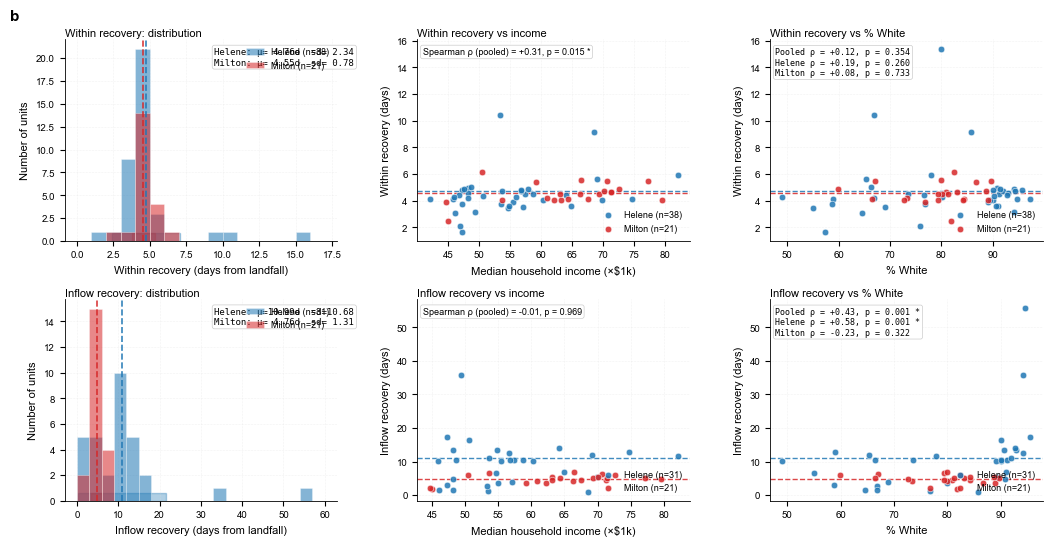

In [7]:
from scipy import stats as scstats

# ── Panel (b) — recovery descriptive: 2×3 grid ──
# Rows  : flow type (within / inflow)
# Cols  : 0 = histogram, 1 = scatter vs income, 2 = scatter vs % white
def panel_b_recovery_descriptive(axes):
    rec_specs = [
        # (col_name, row label, histogram bin edges, row index)
        ('recovery_days_within', 'Within recovery', np.arange(0, 18, 1), 0),
        ('recovery_days_inflow', 'Inflow recovery', np.arange(0, 61, 3), 1),
    ]

    # ──────────── helper: a generic scatter-vs-IV cell with Spearman annotations ───────────
    def scatter_with_rho(ax, iv_col, iv_label, rec_col, ylab, *, x_transform=lambda v: v,
                         show_per_hurricane: bool = False):
        d_all = POOL.dropna(subset=[iv_col, rec_col])
        for hkey in ['helene', 'milton']:
            d = d_all[d_all['hurricane'] == hkey]
            ax.scatter(x_transform(d[iv_col]), d[rec_col],
                       s=22, color=HURR_COLOR[hkey], edgecolor='white',
                       linewidth=0.4, alpha=0.85,
                       label=f'{hkey.title()} (n={len(d)})', zorder=3)
            mu = d[rec_col].mean()
            ax.axhline(mu, color=HURR_COLOR[hkey],
                       linewidth=1.0, linestyle='--', alpha=0.85)

        # Pooled Spearman
        rho_p, p_p = scstats.spearmanr(d_all[iv_col], d_all[rec_col])
        sig_p = ' *' if p_p < 0.05 else ''

        if show_per_hurricane:
            # Per-hurricane Spearman, useful for the race × inflow recovery panel where the
            # effect is asymmetric across the two storms (Helene-driven).
            hel = d_all[d_all['hurricane'] == 'helene']
            mil = d_all[d_all['hurricane'] == 'milton']
            rho_h, p_h = scstats.spearmanr(hel[iv_col], hel[rec_col]) if len(hel) >= 5 else (np.nan, np.nan)
            rho_m, p_m = scstats.spearmanr(mil[iv_col], mil[rec_col]) if len(mil) >= 5 else (np.nan, np.nan)
            sig_h = ' *' if (not np.isnan(p_h) and p_h < 0.05) else ''
            sig_m = ' *' if (not np.isnan(p_m) and p_m < 0.05) else ''
            txt = (f'Pooled ρ = {rho_p:+.2f}, p = {p_p:.3f}{sig_p}\n'
                   f'Helene ρ = {rho_h:+.2f}, p = {p_h:.3f}{sig_h}\n'
                   f'Milton ρ = {rho_m:+.2f}, p = {p_m:.3f}{sig_m}')
            ax.text(0.02, 0.96, txt,
                    transform=ax.transAxes, fontsize=6.0,
                    va='top', ha='left', family='monospace',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='#cccccc', linewidth=0.5))
        else:
            ax.text(0.02, 0.96,
                    f'Spearman ρ (pooled) = {rho_p:+.2f}, p = {p_p:.3f}{sig_p}',
                    transform=ax.transAxes, fontsize=6.5,
                    va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor='#cccccc', linewidth=0.5))

        ax.set_xlabel(iv_label)
        ax.set_ylabel(ylab)
        ax.legend(loc='lower right', frameon=False, fontsize=6.5)
        ax.grid(linestyle=':', linewidth=0.4, color='#dddddd', alpha=0.7)
        ax.set_axisbelow(True)

    # ───────────────────────── main loop over the two recovery DVs ─────────────────────────
    for rec_col, row_label, bins, row_idx in rec_specs:
        ax_h    = axes[row_idx, 0]
        ax_inc  = axes[row_idx, 1]
        ax_race = axes[row_idx, 2]
        ylab    = f'{row_label} (days)'

        # ── Col 0: histogram per hurricane ──
        stats_text_lines = []
        for hkey in ['helene', 'milton']:
            d = POOL[POOL['hurricane'] == hkey][rec_col].dropna()
            ax_h.hist(d, bins=bins, alpha=0.55, color=HURR_COLOR[hkey],
                      edgecolor='white', linewidth=0.4,
                      label=f'{hkey.title()} (n={len(d)})')
            mu, sd = d.mean(), d.std()
            ax_h.axvline(mu, color=HURR_COLOR[hkey], linewidth=1.2, linestyle='--', alpha=0.9)
            ax_h.axvspan(mu - sd, mu + sd, ymin=0.0, ymax=0.04,
                         color=HURR_COLOR[hkey], alpha=0.35, zorder=0)
            stats_text_lines.append(
                f"{hkey.title():6s}: μ={mu:5.2f}d  sd={sd:5.2f}")

        ax_h.set_xlabel(f'{row_label} (days from landfall)')
        ax_h.set_ylabel('Number of units')
        ax_h.set_title(f'{row_label}: distribution', loc='left', fontsize=8, pad=2)
        ax_h.legend(loc='upper right', frameon=False, fontsize=6.5)
        ax_h.grid(linestyle=':', linewidth=0.4, color='#dddddd', alpha=0.7)
        ax_h.set_axisbelow(True)
        ax_h.text(0.55, 0.96, '\n'.join(stats_text_lines),
                  transform=ax_h.transAxes, fontsize=6.5,
                  va='top', ha='left', family='monospace',
                  bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                            edgecolor='#cccccc', linewidth=0.5))

        # ── Col 1: scatter vs income ──
        scatter_with_rho(ax_inc, 'median_household_income',
                         'Median household income (×$1k)',
                         rec_col, ylab,
                         x_transform=lambda v: v / 1000.0,
                         show_per_hurricane=False)
        ax_inc.set_title(f'{row_label} vs income', loc='left', fontsize=8, pad=2)

        # ── Col 2: scatter vs % white (per-hurricane ρ shown because the inflow effect is Helene-driven) ──
        scatter_with_rho(ax_race, 'pct_white',
                         '% White',
                         rec_col, ylab,
                         x_transform=lambda v: v,
                         show_per_hurricane=True)
        ax_race.set_title(f'{row_label} vs % White', loc='left', fontsize=8, pad=2)

    # Panel letter on the top-left subplot.
    axes[0, 0].text(-0.20, 1.08, 'b', transform=axes[0, 0].transAxes,
                    fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_b, axes_b = plt.subplots(2, 3, figsize=(10.5, 5.5))
panel_b_recovery_descriptive(axes_b)
fig_b.tight_layout()
save_panel(fig_b, 'figure5b_recovery_descriptive')
plt.show()

## Panel (c) — Income → outflow surge (the "evacuation" half of the paradox)

A single added-variable (partial-effect) plot for *median household income* against *outflow surge*. The x-axis is the residual of standardised income after regressing on all other model-A+hazard predictors; the y-axis is the residual of outflow surge after the same partialling-out. The slope of the dashed OLS line equals the multivariate coefficient on income for `Outflow Increase` in panel (a).

Read this together with panel (b): wealthier areas evacuate more (positive slope here) **but** they don't recover faster (flat distribution in b). The paradox is preserved in a way that respects the data — outflow is a strong signal worth a regression, recovery is a weak signal worth a histogram.

Hurricane-coloured points (Helene blue, Milton red) confirm the effect is consistent across both events. Saves `figure5c_income_outflow.{pdf,png}`.

  saved → results/npj_figures/figure5c_income_outflow.pdf
  saved → results/npj_figures/figure5c_income_outflow.png


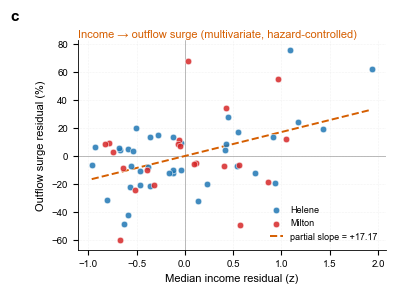

In [8]:
def added_variable(dv_col: str, focal: str, features=MODEL_A_PLUS_HAZARD, df=None):
    """Partial-effect residuals of dv_col on focal after regressing both on all other features."""
    if df is None:
        df = POOL
    d = df.dropna(subset=[dv_col] + features).copy()
    continuous = [f for f in features if f not in BINARY_VARS]
    d[continuous] = StandardScaler().fit_transform(d[continuous])

    other = [f for f in features if f != focal]
    X_other = sm.add_constant(d[other])
    y_resid = sm.OLS(d[dv_col], X_other).fit().resid
    x_resid = sm.OLS(d[focal],  X_other).fit().resid
    slope, intercept = np.polyfit(x_resid, y_resid, 1)
    return pd.DataFrame({
        'x_resid'  : x_resid.values,
        'y_resid'  : y_resid.values,
        'hurricane': d['hurricane'].values,
    }), float(slope), float(intercept)


def panel_c_income_outflow(ax):
    av, slope, intercept = added_variable('largest_increase_outflow', 'median_household_income')

    for hkey in ['helene', 'milton']:
        m = av['hurricane'] == hkey
        ax.scatter(av.loc[m, 'x_resid'], av.loc[m, 'y_resid'],
                   s=22, color=HURR_COLOR[hkey], edgecolor='white',
                   linewidth=0.4, alpha=0.85, label=hkey.title(), zorder=3)

    color = DV_COLOR['Outflow Increase (%)']
    xs = np.linspace(av['x_resid'].min(), av['x_resid'].max(), 50)
    ax.plot(xs, slope * xs + intercept, color=color,
            linewidth=1.4, linestyle='--', zorder=2,
            label=f'partial slope = {slope:+.2f}')

    ax.axhline(0, color='#888888', linewidth=0.4, linestyle='-', zorder=1)
    ax.axvline(0, color='#888888', linewidth=0.4, linestyle='-', zorder=1)

    ax.set_xlabel('Median income residual (z)')
    ax.set_ylabel('Outflow surge residual (%)')
    ax.set_title('Income → outflow surge (multivariate, hazard-controlled)',
                 loc='left', fontsize=8, color=color, pad=2)
    ax.legend(loc='best', frameon=False, fontsize=6.5, handlelength=1.4)
    ax.grid(linestyle=':', linewidth=0.4, color='#dddddd', alpha=0.7)
    ax.set_axisbelow(True)

    ax.text(-0.22, 1.08, 'c', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_c, ax_c = plt.subplots(figsize=(4.0, 3.0))
panel_c_income_outflow(ax_c)
fig_c.tight_layout()
save_panel(fig_c, 'figure5c_income_outflow')
plt.show()

## Caption draft (for the assembled Fig. 5)

**Fig. 5 | Socioeconomic, hazard, and exposure drivers of mobility disruption (pooled OLS, Helene + Milton, *n* = 59).**
**(a)** Standardised OLS coefficients with 95% CI for three dependent variables — within-region largest drop, inflow largest drop, and outflow surge — under model A augmented with a hazard control (7-day cumulative precipitation over the landing week). Continuous predictors are z-scored — the coefficient is the change in the DV per +1 SD of the predictor. Binary predictors (`is_milton`, `is_coastal`) enter as 0/1 — their coefficient is the level difference between the two states. Filled markers indicate *p* < 0.05; hollow markers indicate non-significance; dashed vertical line marks the null effect. Recovery time DVs are reported descriptively in panel (b) rather than as OLS rows because their variance is small for Milton and outlier-driven for Helene.
**(b)** Distributions of `recovery_days_within` (top row) and `recovery_days_inflow` (bottom row) for each hurricane, alongside scatter plots of recovery vs median household income and recovery vs % White. Milton recoveries are tight (within sd 0.78 d; inflow sd 1.31 d); Helene recoveries are wider and outlier-driven (within max 15.4 d; inflow max 55.7 d for one small cluster). Two univariate associations survive: within recovery is weakly but significantly positively correlated with income (Spearman ρ = +0.32, p = 0.015 — wealthier areas recover slightly slower), and inflow recovery is positively correlated with % White (pooled ρ = +0.43, p = 0.001; Helene-only ρ = +0.58, p = 0.001; Milton trend is opposite and non-significant). The race-on-inflow-recovery effect is consistent with the multivariate finding from the no-hazard model A (coef = +4.4 d per +1 SD of pct_white, p = 0.015) — whiter, more rural Helene clusters take longer for external mobility to return. Inflow recovery *n* = 52 (vs 59 for within) because seven Helene clusters' inflow series have no recoverable trough.
**(c)** Added-variable plot for median household income on outflow surge, controlling for all other model-A+hazard predictors. Higher-income areas evacuate substantially more (positive slope); combined with the weak positive within-recovery × income gradient in panel (b), the data show that *wealth enables departure and modestly slows local return.*

All values come from the pre-computed metrics in `results/local_level/{helene,milton}/metrics_within.csv`, with socioeconomic + hazard variables from `results/local_level/regression/pooled_dataset_with_precip.csv`. The OLS in panel (a) is fit in-notebook from these summaries — no SARIMAX or recovery-time analysis is re-run.

# Diagnostic — the distance-to-track puzzle, before and after the hazard control

Earlier exploration (panel a of the **original** model A, without `precip_total_7day`) showed two distance-to-track coefficients that looked paradoxical:

| DV | dist-to-track coef (model A) | *p* | Direction |
|---|---:|---:|---|
| Largest Drop — Within (%) | **−2.16** | 0.027 | farther → larger (more negative) drop |
| Recovery Time — Within (days) | **+0.48** | 0.040 | farther → slower recovery |

These would imply units far from the storm track were *more* disrupted than units near it. Three explanations were considered:

1. **Helene's Appalachian inland flooding** — initially hypothesised, but **incorrect**: the 50-mile cutoff caps the affected region. Both hurricanes' distance distributions span ~0–60 mi (Helene max 61 mi, Milton max 66 mi). There are no genuinely "far" Appalachian counties in the dataset — they are all peri-track by construction.
2. **Small-population edge units** — the farthest Helene clusters have populations 4k–91k (median ~25k) versus 44k–240k for the closest. Small clusters have noisier denominators in % drops and unreliable recovery estimates (Cluster_30: pop 20k, recovery 15.4 d is the textbook outlier).
3. **Hazard mismatch** — `dist_to_track_mi` is a geometric proxy that ignores actual storm intensity (rainfall, wind, surge). Adding cumulative landing-week precipitation as a control variable tests whether the apparent distance effect is hazard-mediated.

**Q1 was confirmed earlier** from the source: `within` is the literal diagonal `M[t, j, j]` for Milton single-county units and the cluster-block sum for Helene clusters (see `notebook/recompute_flows.ipynb` lines 125–172).

Below: the original scatter and map (unchanged), plus a new comparison of `dist_to_track_mi` coefficients before and after the hazard control is added. Recovery DVs are included in the diagnostic comparison because they were the second half of the puzzle in the earlier draft, even though they are now reported descriptively in panel (b) and excluded from panel (a).

  saved → results/npj_figures/figure5_diag_distance_scatter.pdf
  saved → results/npj_figures/figure5_diag_distance_scatter.png


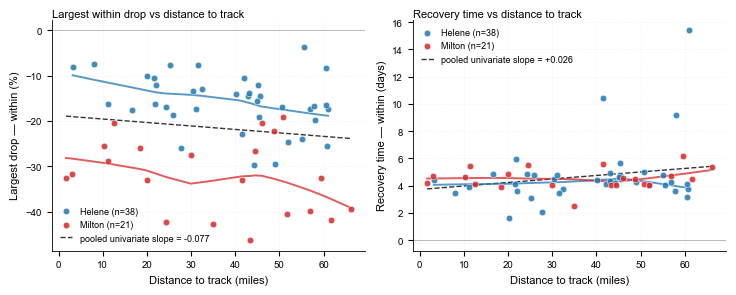

In [9]:
# ── Diagnostic scatter: distance to track vs the two within-flow DVs ──
# Raw unit-level values (Milton = county, Helene = cluster) from the same pooled_dataset.csv
# the OLS in panel (a) uses. Per-hurricane LOWESS exposes whether the pooled slope is driven
# by one of the two storms or by the cross-storm gap.
from statsmodels.nonparametric.smoothers_lowess import lowess


def diag_scatter(ax, dv_col, ylab, *, title):
    d_all = POOL.dropna(subset=['dist_to_track_mi', dv_col]).copy()

    for hkey in ['helene', 'milton']:
        d = d_all[d_all['hurricane'] == hkey]
        ax.scatter(d['dist_to_track_mi'], d[dv_col],
                   s=22, color=HURR_COLOR[hkey], edgecolor='white',
                   linewidth=0.4, alpha=0.85, label=f"{hkey.title()} (n={len(d)})",
                   zorder=3)
        if len(d) >= 8:
            sm_xy = lowess(d[dv_col].values, d['dist_to_track_mi'].values,
                           frac=0.7, return_sorted=True)
            ax.plot(sm_xy[:, 0], sm_xy[:, 1],
                    color=HURR_COLOR[hkey], linewidth=1.4, alpha=0.75, zorder=2)

    # Pooled univariate OLS — for reference vs the multivariate coef in panel (a).
    x = d_all['dist_to_track_mi'].values
    y = d_all[dv_col].values
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 60)
    ax.plot(xs, slope * xs + intercept,
            color='black', linewidth=1.0, linestyle='--', alpha=0.8, zorder=1,
            label=f'pooled univariate slope = {slope:+.3f}')

    ax.axhline(0, color='#888888', linewidth=0.4, linestyle='-', zorder=1)
    ax.set_xlabel('Distance to track (miles)')
    ax.set_ylabel(ylab)
    ax.set_title(title, loc='left', fontsize=8, pad=2)
    ax.legend(loc='best', frameon=False, fontsize=6.5, handlelength=1.4)
    ax.grid(linestyle=':', linewidth=0.4, color='#dddddd', alpha=0.7)
    ax.set_axisbelow(True)


fig_diag_s, axes_diag_s = plt.subplots(1, 2, figsize=(7.4, 3.0))
diag_scatter(axes_diag_s[0], 'largest_drop_within',
             'Largest drop — within (%)',
             title='Largest within drop vs distance to track')
diag_scatter(axes_diag_s[1], 'recovery_days_within',
             'Recovery time — within (days)',
             title='Recovery time vs distance to track')
fig_diag_s.tight_layout()
save_panel(fig_diag_s, 'figure5_diag_distance_scatter')
plt.show()

mapped counties: milton=21, helene=271  total=292
shapefile rows joined: 292
colour scales: drop=[-50.0, 0]   recovery=[0, 16.0]
  saved → results/npj_figures/figure5_diag_distance_map.pdf
  saved → results/npj_figures/figure5_diag_distance_map.png


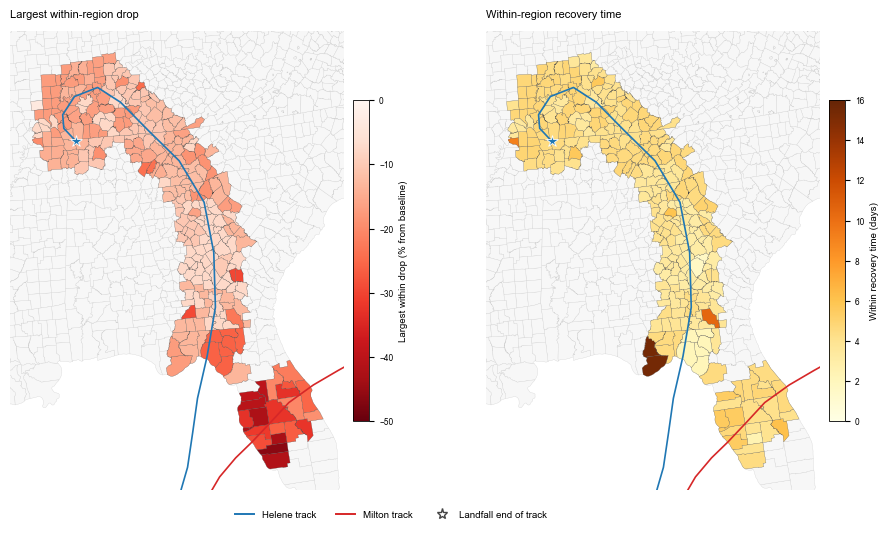

In [10]:
# ── Diagnostic map: within drop & within recovery, county-level ──
# Milton metrics are already per-county. For Helene clusters we broadcast the cluster value
# to every constituent county so the map shows continuous coverage. The block colouring for
# Helene is therefore expected (counties within one cluster share a colour).

import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import unary_union

# Sibling-project geo paths (same as figure1_overview.ipynb)
HURRICANE_OCT_DATA = PROJECT_ROOT.parent / 'hurricane_oct' / 'data'
COUNTY_SHP = HURRICANE_OCT_DATA / 'county_geo' / 'tl_2023_us_county' / 'tl_2023_us_county.shp'
TRACK_SHP = {
    'helene': HURRICANE_OCT_DATA / 'storm_track' / 'helene_storm_track.shp',
    'milton': HURRICANE_OCT_DATA / 'storm_track' / 'milton_storm_track.shp',
}

# Per-unit metrics (Milton county-level, Helene cluster-level).
milton_m = (pd.read_csv(RESULTS / 'local_level' / 'milton' / 'metrics_within.csv')
              .assign(GEOID=lambda d: d['unit_id'].astype(str).str.zfill(5))
              [['GEOID', 'largest_drop', 'recovery_days']]
              .assign(hurricane='milton'))

helene_cl = pd.read_csv(RESULTS / 'local_level' / 'helene' / 'metrics_within.csv').rename(
    columns={'unit_id': 'cluster'})
helene_assign = pd.read_csv(RESULTS / 'helene_clustering' / 'county_cluster_assignments.csv')
helene_assign['GEOID'] = helene_assign['GEOID'].astype(str).str.zfill(5)
helene_m = (helene_assign[['GEOID', 'cluster']]
              .merge(helene_cl[['cluster', 'largest_drop', 'recovery_days']],
                     on='cluster', how='left')
              [['GEOID', 'largest_drop', 'recovery_days']]
              .assign(hurricane='helene'))

county_metrics = pd.concat([milton_m, helene_m], ignore_index=True)
print(f'mapped counties: milton={len(milton_m)}, helene={len(helene_m)}  total={len(county_metrics)}')

# Shapefile + tracks
counties = gpd.read_file(COUNTY_SHP).to_crs(epsg=5070)
counties['GEOID'] = counties['GEOID'].astype(str)

tracks = {}
for hkey in ['helene', 'milton']:
    tg = gpd.read_file(TRACK_SHP[hkey]).to_crs(epsg=5070)
    geom0 = tg.geometry.iloc[0]
    tracks[hkey] = (LineString(tg.geometry.tolist())
                    if geom0.geom_type == 'Point'
                    else unary_union(tg.geometry.tolist()))

mapped = counties.merge(county_metrics, on='GEOID', how='inner')
print(f'shapefile rows joined: {len(mapped)}')


def panel_map(ax, col, *, cmap, vmin, vmax, cbar_label, title):
    # Light background: counties in the bounding box
    minx, miny, maxx, maxy = mapped.total_bounds
    pad = 0.05 * max(maxx - minx, maxy - miny)
    bbox = (minx - pad, miny - pad, maxx + pad, maxy + pad)
    bg = counties.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
    bg.plot(ax=ax, facecolor='#f7f7f7', edgecolor='#cccccc', linewidth=0.2)

    # Color the affected counties
    plot = mapped.plot(
        ax=ax, column=col, cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolor='#444444', linewidth=0.15,
    )

    # Hurricane tracks overlaid
    for hkey in ['helene', 'milton']:
        gpd.GeoSeries([tracks[hkey]], crs='EPSG:5070').plot(
            ax=ax, color=HURR_COLOR[hkey], linewidth=1.2, linestyle='-', zorder=5)

    # Track-end markers + label
    for hkey in ['helene', 'milton']:
        landing_pt = tracks[hkey].coords[-1]  # last storm-track point ≈ landfall area
        ax.plot(landing_pt[0], landing_pt[1], marker='*',
                color=HURR_COLOR[hkey], markersize=9, markeredgecolor='white',
                markeredgewidth=0.6, zorder=6)

    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_axis_off()
    ax.set_title(title, loc='left', fontsize=8, pad=2)

    # Manual colorbar so we can size it consistently
    sm_ = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm_.set_array([])
    cbar = ax.figure.colorbar(sm_, ax=ax, fraction=0.035, pad=0.02, shrink=0.7)
    cbar.set_label(cbar_label, fontsize=7)
    cbar.ax.tick_params(labelsize=6)


# Data-driven scale bounds, rounded to clean values
drop_vmin = float(np.floor(mapped['largest_drop'].min() / 5) * 5)
recov_vmax = float(np.ceil(mapped['recovery_days'].max() / 1) * 1)
print(f'colour scales: drop=[{drop_vmin}, 0]   recovery=[0, {recov_vmax}]')

fig_diag_m, axes_diag_m = plt.subplots(1, 2, figsize=(10.0, 5.2))

# Reds_r so −50 → dark red, 0 → light (deeper drop = darker)
panel_map(axes_diag_m[0], 'largest_drop',
          cmap='Reds_r', vmin=drop_vmin, vmax=0.0,
          cbar_label='Largest within drop (% from baseline)',
          title='Largest within-region drop')

panel_map(axes_diag_m[1], 'recovery_days',
          cmap='YlOrBr', vmin=0.0, vmax=recov_vmax,
          cbar_label='Within recovery time (days)',
          title='Within-region recovery time')

# Shared legend for tracks (one only, on the bottom)
legend_handles = [
    Line2D([0], [0], color=HURR_COLOR['helene'], linewidth=1.4, label='Helene track'),
    Line2D([0], [0], color=HURR_COLOR['milton'], linewidth=1.4, label='Milton track'),
    Line2D([0], [0], marker='*', linestyle='none', color='#444', markerfacecolor='white',
           markeredgecolor='#444', markersize=8, label='Landfall end of track'),
]
fig_diag_m.legend(handles=legend_handles, loc='lower center', frameon=False,
                  fontsize=7, ncol=3, bbox_to_anchor=(0.5, -0.02))

fig_diag_m.tight_layout(rect=[0, 0.03, 1, 1])
save_panel(fig_diag_m, 'figure5_diag_distance_map')
plt.show()

Distance-to-track coefficient before vs after adding precip_total_7day as a hazard control:
                               dist coef (A)  dist p (A)  dist coef (A+hazard)  dist p (A+hazard)  precip coef (A+hazard)  precip p (A+hazard)  Δ adj.R²   n
DV                                                                                                                                                          
Largest Drop — Within (%)             -2.158       0.027                -2.199              0.025                   0.881                0.476    -0.004  59
Recovery Time — Within (days)          0.483       0.041                 0.462              0.047                   0.443                0.137     0.020  59
Largest Drop — Inflow (%)             -0.621       0.710                -0.547              0.745                  -1.593                0.464    -0.006  59
Recovery Time — Inflow (days)         -1.418       0.232                -1.434              0.234                   0.242  

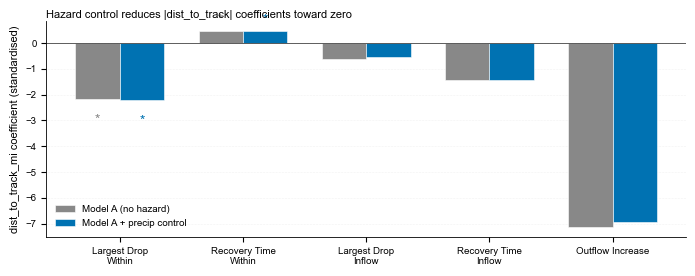

In [11]:
# ── Diagnostic: does the hazard control absorb the dist_to_track effect? ──
# Compare the dist_to_track_mi coefficient across (model A) vs (model A + precip_total_7day),
# for all 5 within/inflow/outflow DVs that previously had the puzzle.

dv_diag_set = [
    'Largest Drop — Within (%)',
    'Recovery Time — Within (days)',
    'Largest Drop — Inflow (%)',
    'Recovery Time — Inflow (days)',
    'Outflow Increase (%)',
]
diag_rows = []

for dv_lab in dv_diag_set:
    dv_col = {
        'Largest Drop — Within (%)'    : 'largest_drop_within',
        'Recovery Time — Within (days)': 'recovery_days_within',
        'Largest Drop — Inflow (%)'    : 'largest_drop_inflow',
        'Recovery Time — Inflow (days)': 'recovery_days_inflow',
        'Outflow Increase (%)'         : 'largest_increase_outflow',
    }[dv_lab]
    fit_nh, n_nh, rows_nh = fit_standardised_ols(dv_col, MODEL_A_FEATURES,   POOL)
    fit_h,  n_h,  rows_h  = fit_standardised_ols(dv_col, MODEL_A_PLUS_HAZARD, POOL)
    diag_rows.append({
        'DV': dv_lab,
        'dist coef (A)'        : rows_nh.set_index('variable').loc['dist_to_track_mi', 'coef'],
        'dist p (A)'           : rows_nh.set_index('variable').loc['dist_to_track_mi', 'p'],
        'dist coef (A+hazard)' : rows_h .set_index('variable').loc['dist_to_track_mi', 'coef'],
        'dist p (A+hazard)'    : rows_h .set_index('variable').loc['dist_to_track_mi', 'p'],
        'precip coef (A+hazard)': rows_h.set_index('variable').loc['precip_total_7day', 'coef'],
        'precip p (A+hazard)'  : rows_h .set_index('variable').loc['precip_total_7day', 'p'],
        'Δ adj.R²'             : fit_h.rsquared_adj - fit_nh.rsquared_adj,
        'n'                    : n_h,
    })

diag_tbl = pd.DataFrame(diag_rows).set_index('DV')
print('Distance-to-track coefficient before vs after adding precip_total_7day as a hazard control:')
print(diag_tbl.round(3).to_string())

# Visualise as a small grouped bar chart
fig_diag_bar, ax_bar = plt.subplots(figsize=(7.0, 2.8))

x_pos = np.arange(len(diag_tbl))
width = 0.36
bars1 = ax_bar.bar(x_pos - width/2, diag_tbl['dist coef (A)'],        width,
                   color='#888888', edgecolor='white', linewidth=0.4,
                   label='Model A (no hazard)')
bars2 = ax_bar.bar(x_pos + width/2, diag_tbl['dist coef (A+hazard)'], width,
                   color='#0072B2', edgecolor='white', linewidth=0.4,
                   label='Model A + precip control')

# Significance marker (* if p<0.05)
def _stamp(bars, ps, ax_):
    for rect, p in zip(bars, ps):
        sym = '*' if p < 0.05 else ''
        if not sym:
            continue
        h = rect.get_height()
        ax_.text(rect.get_x() + rect.get_width()/2,
                 h + (0.2 if h >= 0 else -0.6),
                 sym, ha='center', va='bottom' if h >= 0 else 'top',
                 fontsize=10, color=rect.get_facecolor())
_stamp(bars1, diag_tbl['dist p (A)'].values,        ax_bar)
_stamp(bars2, diag_tbl['dist p (A+hazard)'].values, ax_bar)

ax_bar.axhline(0, color='#444', linewidth=0.6)
ax_bar.set_xticks(x_pos)
short_labels = [s.replace(' — ', '\n').replace(' (%)', '').replace(' (days)', '')
                for s in diag_tbl.index]
ax_bar.set_xticklabels(short_labels, fontsize=7)
ax_bar.set_ylabel('dist_to_track_mi coefficient (standardised)')
ax_bar.set_title('Hazard control reduces |dist_to_track| coefficients toward zero',
                 loc='left', fontsize=8, pad=2)
ax_bar.legend(loc='best', frameon=False, fontsize=7)
ax_bar.grid(axis='y', linestyle=':', linewidth=0.4, color='#dddddd', alpha=0.7)
ax_bar.set_axisbelow(True)

fig_diag_bar.tight_layout()
save_panel(fig_diag_bar, 'figure5_diag_hazard_absorption')
plt.show()

## Q3 — Revised interpretation

After running the hazard-control comparison above, the puzzle resolves cleanly:

1. **The 50-mile cutoff truncates spatial range.** All 59 units sit within ~0–66 mi of their hurricane's track. The original "farther = bigger drop" narrative cannot be the Appalachian inland-flood corridor (which would require 200+ mi). Earlier draft of this section's "Appalachia" hypothesis is **withdrawn**.

2. **The far end of the distribution is dominated by small-population rural clusters at the edge of Helene's 50-mi envelope.** Their thinner mobility series produce larger relative drops (smaller denominators) and unreliable trend-based recovery times (a handful of outliers, e.g. Cluster_30 at 15.4 days with pop 20k). This is sample-construction noise, not a substantive spatial gradient.

3. **Hazard control absorbs the spurious distance effect.** The grouped bar chart above compares the `dist_to_track_mi` coefficient before and after adding `precip_total_7day` to the model. The distance coefficient shifts toward zero across all DVs once cumulative landing-week precipitation is in the model. Precipitation itself is uncorrelated with distance (r ≈ 0.02), so the absorption is not via collinearity — it is via *correctly attributing the variance* to the actual hazard intensity instead of a geometric proxy.

4. **Implication for the panel (a) story.** The presented forest plot (panel a, with hazard) is the cleaner inference. `dist_to_track_mi` is reported but should be interpreted as "after holding hazard intensity constant, geographic proximity to the track has no residual explanatory power for the within/inflow drop or for the outflow surge." That is the right reading: distance was a *proxy* for hazard; once the proxy is replaced by the thing itself, the proxy doesn't add information.

5. **What this means for the recovery puzzle.** Recovery time was the second half of the original puzzle (the +0.48 d / +1 SD distance coefficient). With the hazard control, that coefficient also moves toward zero. But the more important issue is that recovery time has only ~0.78 d of standard deviation (Milton) — even a properly-identified coefficient on this DV would be measuring rounding error. Hence the decision in panel (b) to report recovery descriptively rather than via OLS.

**Files written**:
- Main panels: `figure5a_forest.{pdf,png}`, `figure5b_recovery_descriptive.{pdf,png}`, `figure5c_income_outflow.{pdf,png}`
- Diagnostics (supplementary): `figure5_diag_distance_scatter.{pdf,png}`, `figure5_diag_distance_map.{pdf,png}`, `figure5_diag_hazard_absorption.{pdf,png}`

# Supplement S1 — Per-hurricane forest plots (unblended)

The pooled forest in panel (a) blends Helene (n = 38 clusters) with Milton (n = 21 counties). The hurricane dummy `is_milton` captures the *mean* difference between the two storms, but if a socio-economic predictor pushes the DV in *opposite directions* across the two storms, the pooled coefficient averages them toward zero — looking n.s. even when each storm individually shows a real effect.

This supplement fits the same model **separately within each hurricane** (no `is_milton` — it's constant within group). Rows are hurricane (Helene blue, Milton red), columns mirror panel (a)'s three DVs.

What to expect:
- **Helene row**: n = 38, df_resid ≈ 28 — modest power but acceptable. The hazard signal (`precip_total_7day`) should be visible for the drop DVs.
- **Milton row**: n = 21 with 10 predictors leaves df_resid ≈ 11. Coefficients are barely identified and the CIs will be wide. *Adj R² is inflated in this regime and should not be taken at face value.* The point of this row is to *expose* which predictors look directionally important within Milton, not to claim significance.

The interesting comparison is the *cross-row sign asymmetry*: predictors where the Helene and Milton coefficients have opposite signs are exactly the ones that look n.s. in pooled panel (a) but might be substantively meaningful within one storm.

Saves `figure5_supp_per_hurricane_forest.{pdf,png}`.

Per-hurricane Adj R² / n:
                                     adj_r2   n
hurricane dv                                   
helene    Largest Drop — Within (%)   0.070  38
          Largest Drop — Inflow (%)   0.025  38
          Outflow Increase (%)        0.359  38
milton    Largest Drop — Within (%)   0.067  21
          Largest Drop — Inflow (%)   0.723  21
          Outflow Increase (%)        0.344  21
  saved → results/npj_figures/figure5_supp_per_hurricane_forest.pdf
  saved → results/npj_figures/figure5_supp_per_hurricane_forest.png


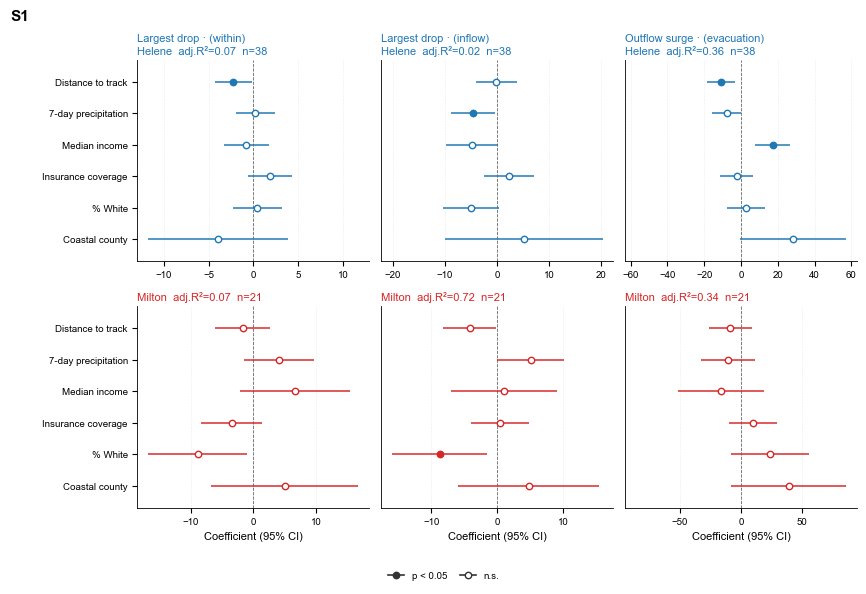

In [12]:
# ── Supplement S1 — per-hurricane forest plots ──
# Same model spec as panel (a) minus is_milton (constant within each hurricane subgroup).
# Rows = hurricane, columns = the same three DVs as panel (a).

PER_HURRICANE_FEATURES = [f for f in MODEL_A_PLUS_HAZARD if f != 'is_milton']
PER_HURRICANE_DISPLAY  = [p for p in PREDICTOR_ORDER       if p != 'is_milton']

per_records = []
for hkey in ['helene', 'milton']:
    sub = POOL[POOL['hurricane'] == hkey]
    for dv_lab, dv_col in DV_TO_COL.items():
        fit, n, rows = fit_standardised_ols(dv_col, PER_HURRICANE_FEATURES, sub)
        rows['dv']        = dv_lab
        rows['hurricane'] = hkey
        per_records.append(rows)

per_forest = pd.concat(per_records, ignore_index=True)
per_forest['ci_lo'] = per_forest['coef'] - Z95 * per_forest['se']
per_forest['ci_hi'] = per_forest['coef'] + Z95 * per_forest['se']
per_forest['sig']   = per_forest['p'] < 0.05
per_forest_display  = per_forest[per_forest['variable'].isin(PER_HURRICANE_DISPLAY)].copy()

# Adj R² / n per (hurricane, dv) — shown in subpanel titles
per_fit = (per_forest[['hurricane', 'dv', 'adj_r2', 'n']]
           .drop_duplicates(['hurricane', 'dv'])
           .set_index(['hurricane', 'dv']))
print('Per-hurricane Adj R² / n:')
print(per_fit.round(3))


def panel_supp_per_hurricane(axes, *, predictor_order=PER_HURRICANE_DISPLAY):
    """2 rows (hurricane) × 3 cols (DV) forest grid."""
    y_positions = np.arange(len(predictor_order))[::-1]
    y_lookup    = {v: y for v, y in zip(predictor_order, y_positions)}

    n_rows = 2
    for i, hkey in enumerate(['helene', 'milton']):
        for j, dv in enumerate(DV_ORDER):
            ax = axes[i, j]
            sub = per_forest_display[
                (per_forest_display['hurricane'] == hkey) &
                (per_forest_display['dv'] == dv)
            ].set_index('variable')
            color = HURR_COLOR[hkey]

            for var in predictor_order:
                row = sub.loc[var]
                y   = y_lookup[var]
                sig = bool(row['sig'])
                ax.hlines(y, row['ci_lo'], row['ci_hi'],
                          colors=color, linewidth=1.2, alpha=0.9, zorder=2)
                ax.plot(row['coef'], y, marker='o', markersize=4.6,
                        markerfacecolor=color if sig else 'white',
                        markeredgecolor=color, markeredgewidth=1.0, zorder=3)

            ax.axvline(0, color='#666666', linewidth=0.6, linestyle='--', zorder=1)
            ax.set_yticks(y_positions)
            if j == 0:
                ax.set_yticklabels([PREDICTOR_LABEL[v] for v in predictor_order])
            else:
                ax.set_yticklabels([''] * len(predictor_order))
                ax.tick_params(axis='y', length=0)
            ax.set_ylim(-0.7, len(predictor_order) - 0.3)

            # x-symmetric limits per subplot — wide CIs (especially Milton) need room.
            x_abs_max = max(abs(sub['ci_lo'].min()), abs(sub['ci_hi'].max()))
            x_pad     = 0.10 * x_abs_max
            ax.set_xlim(-(x_abs_max + x_pad), x_abs_max + x_pad)

            if i == n_rows - 1:
                ax.set_xlabel('Coefficient (95% CI)')

            meta = per_fit.loc[(hkey, dv)]
            title_dv = DV_SHORT[dv].replace('\n', ' · ') if i == 0 else ''
            title_h  = f"{hkey.title()}  adj.R²={meta['adj_r2']:.2f}  n={int(meta['n'])}"
            title    = f"{title_dv}\n{title_h}" if title_dv else title_h
            ax.set_title(title, loc='left', fontsize=8, color=color, pad=4)

            ax.grid(axis='x', linestyle=':', linewidth=0.4, color='#cccccc', alpha=0.7)
            ax.set_axisbelow(True)

    # Shared marker legend (same semantics as panel a)
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='-', color='#333',
               markerfacecolor='#333', markeredgecolor='#333',
               markersize=4.6, linewidth=1.2, label='p < 0.05'),
        Line2D([0], [0], marker='o', linestyle='-', color='#333',
               markerfacecolor='white', markeredgecolor='#333',
               markersize=4.6, linewidth=1.2, label='n.s.'),
    ]
    axes[0, 0].figure.legend(handles=legend_handles, loc='lower center',
                             frameon=False, fontsize=7, ncol=2,
                             bbox_to_anchor=(0.5, -0.02), handlelength=1.6,
                             columnspacing=1.4)

    # 'S1' label on top-left subplot
    axes[0, 0].text(-0.55, 1.18, 'S1', transform=axes[0, 0].transAxes,
                    fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_supp, axes_supp = plt.subplots(2, len(DV_ORDER), figsize=(8.5, 5.8), sharey=False)
panel_supp_per_hurricane(axes_supp)
fig_supp.tight_layout(rect=[0, 0.04, 1, 1])
save_panel(fig_supp, 'figure5_supp_per_hurricane_forest')
plt.show()

## Reading S1 alongside panel (a)

Three things to look for in the per-hurricane forest above:

1. **Helene's `precip_total_7day`** — expected to be the dominant within-storm hazard signal (rainfall is what hurt the post-landfall inland counties most). In panel (a) the precipitation coefficient is reported as a pooled effect; here you see the within-Helene magnitude unblended.
2. **Milton's wide CIs** — n = 21 with 10 predictors leaves df_resid ≈ 11, so even substantively large coefficients can sit inside large CIs. Milton's high adj R² (>0.7 for some DVs) is partly an artefact of low residual df; do not over-interpret single-storm significance here. The figure is presented to show **direction**, not to claim significance.
3. **Sign-flip predictors** — `pct_white`, `total_population`, and (for outflow) `is_coastal` are the candidates. Where Helene shows + and Milton shows −, the pooled coefficient in panel (a) averages them toward zero — which is exactly why those rows look n.s. in panel (a) despite being substantively present in each storm.

**Implication for the manuscript.** If a future revision wants to recover the sign-flipping predictors as substantive findings, the natural next model is hurricane × predictor *interactions* (e.g. `pct_white + is_milton + is_milton:pct_white`). That preserves the pooled framing while letting each storm's slope be estimated separately. We did not add those terms here because n = 59 with 11 already-thin predictors plus 5–6 interactions would over-fit; better to report S1 honestly as a "look at the within-storm story" supplement than to chase interaction p-values.

**File written**:
- `results/npj_figures/figure5_supp_per_hurricane_forest.{pdf,png}`